In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [56]:
# all notes for representing normal sin waves and guassian(noisy) ones: (just as a reminder)
#  time formula, starts from 0 upto 2pi (whole cycle, its in rad not sec cuz it's sin wave) and sampling of 100 points so it looks smooth, time is always x label in the plot
# now we produce y which uses the formula y = sin(2pi * frequency * time) so i decide fequency as 1 cuz its cycles per second
# we find y for a pure sin wave, for noisy one we don't need it
# y = np.sin(2 * np.pi * 1 * time)
#guassian nomal is used to add the noise -> normally distrubuted means most of the data are in the center
# loc means most of the errors are at the center, scale means std
# Using the 68-95-99.7 rule:68% of the time, Python will pick a noise value between -0.3 +0.3. (Minor, subtle jitter).
# 95% of the time, Python will pick a noise value between -0.6 and +0.6. 
# (Moderate spikes).Only 0.3% of the time will it pick something larger than 0.9. (An extreme, rare outlier spike). thats y we piacked 0.3 scale cuz outlier is a loud noise
# now for visuaalization, this is for normal sin wave
#plt.plot(time, y, color = 'blue')
# degrees describe how overfit it is, 1 = underfit, 4 = perfect, 15 = overfit. we import polynomialfetures for it
# for diff degrees like 1,4,15 we don't put on a single value of y instead we make y smooth in the curve since it'll be diff in each turn (keep in mind sampling: x = y)
# x same, y= 0.5 * x**3 - x + np.random.normal(mean, std, sampling) 

In [57]:
# added this block to add noise since the common sin wave is pure unlike the requirment
time = np.linspace(0, 2*np.pi, 100)
np.random.seed(42) #gives the same output for every time u run it
y = 0.5 * time**3 - time + np.random.normal(0, 0.4, 100)
x_smooth = np.linspace(0,2*np.pi,200) # more sampling than x
y_smooth = np.sin(x_smooth)
pure_sine = np.sin(time)
noise = np.random.normal(loc = 0, scale = 0.3, size = 100 )  #same size as x

In [58]:
noisy_sine = pure_sine + noise

In [59]:
degrees = [1,4,15]

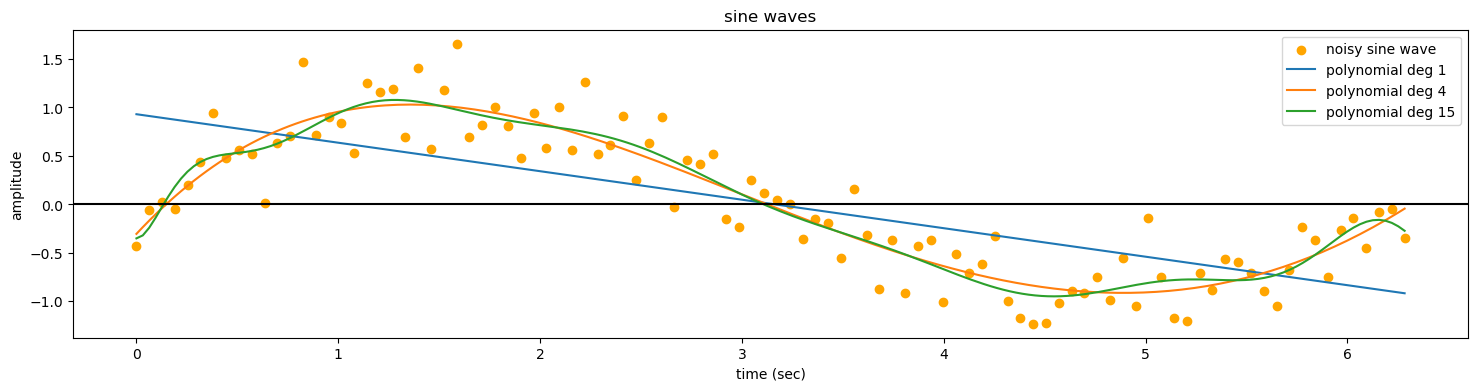

In [60]:
plt.figure(figsize=(18,4))
#plt.plot not here cuz many deg
plt.scatter(time, noisy_sine, label = 'noisy sine wave', color = 'orange') #using scatter plo cuz it's spread out dots, so not to connect them
for degree in degrees:
    #training on raw data
    co_ef= np.polyfit(time, noisy_sine, deg=degree)
    model = np.poly1d(co_ef)
    y_smooth_predict = model(x_smooth)
    plt.plot(x_smooth, y_smooth_predict, label= f'polynomial deg {degree}') #don't mention color here, all will be the same, hard to tell apart
plt.title("sine waves")
plt.xlabel('time (sec)')
plt.ylabel('amplitude')
plt.axhline(0, color ='black')
plt.legend() #adds an explanation, which line is which
plt.show()